# PatchTest8 — v3 linear solve

Requires Python 3.13+ and `uv sync --group v3`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if sys.version_info < (3, 13):
    raise RuntimeError("This notebook requires Python 3.13+")

from pyfem.v3 import load_problem, solve_linear

ROOT = Path.cwd()
if not (ROOT / "skims").exists():
    ROOT = ROOT.parents[1]

loaded = load_problem(ROOT / "skims/patch_test8/problem.toml")
state = solve_linear(loaded)

problem = loaded.problem
u = state[problem.global_dofs[:, 0]]
v = state[problem.global_dofs[:, 1]]

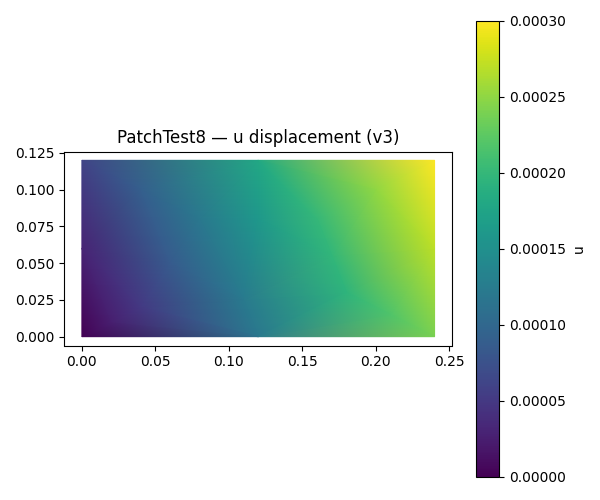

||u|| = 7.563688e-04, ||v|| = 5.793099e-04


In [2]:
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    plt.switch_backend("Agg")

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.tripcolor(
    problem.coords[:, 0],
    problem.coords[:, 1],
    u,
    shading="gouraud",
)
fig.colorbar(sc, ax=ax, label="u")
ax.set_aspect("equal")
ax.set_title("PatchTest8 — u displacement (v3)")
fig.tight_layout()
plt.show()

print(f"||u|| = {np.linalg.norm(u):.6e}, ||v|| = {np.linalg.norm(v):.6e}")